# 15 - LaMa Classical Metrics

**Origin:** Existing Notebook 12

This notebook computes classical full-reference metrics for the final LaMa restoration outputs produced by Notebook 14.

The evaluation compares:

- clean reference vs damaged input,
- clean reference vs LaMa restored output,
- restored-vs-damaged improvement.

The notebook uses the final region policy implemented in `restoration_eval.metrics_classical` and supports the canonical, damage-size, mask-robustness, and eligible synthetic-degradation LaMa datasets.


In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass

    def display(value):
        print(value)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())
print("Config path:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Experiment config not found: {CONFIG_PATH}")


Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True
Config path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Config exists: True


In [2]:
from restoration_eval.metrics_classical import (
    ALL_EVALUATION_REGIONS,
    BASE_REGIONS,
    CLASSICAL_METRIC_COLUMNS,
    MASKED_CASE_REGIONS,
    METRIC_MODULE_NAME,
    METRIC_VERSION,
    compute_classical_metrics_for_restorations,
    expected_metric_rows_from_metadata,
    expected_region_counts_from_metadata,
    summarize_classical_metrics,
    validate_classical_metrics,
)

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

paths_cfg = config.get("paths", {})
preprocessing_cfg = config.get("preprocessing", {})
experiment_cfg = config.get("experiment", {})

TARGET_SIZE = int(
    preprocessing_cfg.get(
        "output_size",
        experiment_cfg.get("image_size", 768),
    )
)
MASK_BBOX_MARGIN = 8
BOUNDARY_WIDTH = 3
PROGRESS_EVERY = 25

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"] / "lama_classical_metrics"
reports_dir = PROJECT_ROOT / paths_cfg["reports_dir"]

lama_metadata_path = processed_metadata_dir / "metadata_restored_lama.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

classical_metrics_path = metrics_dir / "classical_metrics_lama.csv"
classical_summary_path = metrics_dir / "classical_metrics_lama_summary.csv"
classical_diagnostic_cases_path = metrics_dir / "classical_metrics_lama_diagnostic_cases.csv"
classical_audit_path = metrics_dir / "classical_metrics_lama_audit.csv"
classical_manifest_path = reports_dir / "lama_classical_metrics_manifest.json"
classical_report_path = reports_dir / "lama_classical_metrics_report.md"

for output_dir in [metrics_dir, figures_dir, reports_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = "15_metrics_classical_lama"
MODEL_NAME = "lama"
RUN_STARTED_AT_UTC = datetime.now(timezone.utc).isoformat()

print("Classical metric module:", METRIC_MODULE_NAME)
print("Classical metric version:", METRIC_VERSION)
print("Target size:", TARGET_SIZE)
print("Base regions:", BASE_REGIONS)
print("Masked-case regions:", MASKED_CASE_REGIONS)
print("All evaluation regions:", ALL_EVALUATION_REGIONS)

path_contract_df = pd.DataFrame(
    [
        {"artifact": "LaMa restoration metadata", "path": lama_metadata_path, "required_input": True},
        {"artifact": "Processed clean metadata", "path": processed_clean_metadata_path, "required_input": True},
        {"artifact": "Main classical metrics CSV", "path": classical_metrics_path, "required_input": False},
        {"artifact": "Summary CSV", "path": classical_summary_path, "required_input": False},
        {"artifact": "Diagnostic cases CSV", "path": classical_diagnostic_cases_path, "required_input": False},
        {"artifact": "Audit CSV", "path": classical_audit_path, "required_input": False},
        {"artifact": "Figure directory", "path": figures_dir, "required_input": False},
        {"artifact": "JSON manifest", "path": classical_manifest_path, "required_input": False},
        {"artifact": "Markdown report", "path": classical_report_path, "required_input": False},
    ]
)

path_contract_df["path"] = path_contract_df["path"].map(lambda path: str(path.relative_to(PROJECT_ROOT)))

display(path_contract_df)

missing_required_inputs = [
    row["path"]
    for _, row in path_contract_df.iterrows()
    if bool(row["required_input"]) and not (PROJECT_ROOT / row["path"]).exists()
]

if missing_required_inputs:
    raise FileNotFoundError(
        "Missing required Notebook 15 input(s): " + ", ".join(missing_required_inputs)
    )


Classical metric module: restoration_eval.metrics_classical
Classical metric version: 2.0.0
Target size: 768
Base regions: ('full_image', 'content_region')
Masked-case regions: ('masked_region', 'mask_bbox_crop', 'boundary_region', 'outside_mask_region')
All evaluation regions: ('full_image', 'content_region', 'masked_region', 'mask_bbox_crop', 'boundary_region', 'outside_mask_region')


,artifact,path,required_input
0,LaMa restoration metadata,data\processed\metadata\metadata_restored_lama...,True
1,Processed clean metadata,data\processed\metadata\metadata_processed_cle...,True
2,Main classical metrics CSV,outputs\metrics\classical_metrics_lama.csv,False
3,Summary CSV,outputs\metrics\classical_metrics_lama_summary...,False
4,Diagnostic cases CSV,outputs\metrics\classical_metrics_lama_diagnos...,False
5,Audit CSV,outputs\metrics\classical_metrics_lama_audit.csv,False
6,Figure directory,outputs\figures\lama_classical_metrics,False
7,JSON manifest,outputs\reports\lama_classical_metrics_manifes...,False
8,Markdown report,outputs\reports\lama_classical_metrics_report.md,False


In [3]:
def project_relative_path(path_value: str | Path) -> str:
    """Return a stable repository-relative path string when possible."""
    path = Path(path_value)
    if not path.is_absolute():
        return path.as_posix()

    try:
        return path.resolve().relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return str(path.resolve())


def resolve_project_path(path_value: str | Path) -> Path:
    """Resolve an absolute or repository-relative path against PROJECT_ROOT."""
    path = Path(str(path_value))
    if path.is_absolute():
        return path.resolve()
    return (PROJECT_ROOT / path).resolve()


def require_dataframe_columns(
    dataframe: pd.DataFrame,
    required_columns: list[str],
    *,
    dataframe_name: str,
) -> None:
    """Raise a focused error when required columns are absent."""
    missing_columns = [
        column for column in required_columns
        if column not in dataframe.columns
    ]
    if missing_columns:
        raise ValueError(
            f"{dataframe_name} is missing required columns: {missing_columns}"
        )


lama_restored_metadata_df = pd.read_csv(lama_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)

print("Loaded LaMa restoration metadata:", project_relative_path(lama_metadata_path))
print("  Shape:", lama_restored_metadata_df.shape)
print("Loaded processed clean metadata:", project_relative_path(processed_clean_metadata_path))
print("  Shape:", processed_clean_df.shape)

display(lama_restored_metadata_df.head(5))
display(processed_clean_df.head(5))

Loaded LaMa restoration metadata: data/processed/metadata/metadata_restored_lama.csv
  Shape: (410, 218)
Loaded processed clean metadata: data/processed/metadata/metadata_processed_clean.csv
  Shape: (50, 47)


,restoration_case_id,model_name,iopaint_model_name,iopaint_package_version,lama_model_version,restoration_method,inference_mode,restoration_generator_name,restoration_generator_version,execution_device,...,degraded_path,effect_mask_sha256,degraded_sha256,effect_mask_file_size_bytes,degraded_file_size_bytes,lama_mask_area_pixels,lama_staged_input_path,lama_staged_mask_path,lama_staged_output_path,device
0,lama__canonical__canonical__p001_loss_large,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,69018,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
1,lama__canonical__canonical__p001_loss_small,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,18239,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
2,lama__canonical__canonical__p001_mixed_damage,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,45733,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
3,lama__canonical__canonical__p001_scratch_thin,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,12058,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
4,lama__canonical__canonical__p001_zero_control,lama,lama,NaN,iopaint_lama,zero_control_copy,copied_zero_control,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,none


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


In [4]:
lama_required_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
    "status",
]

processed_clean_required_columns = [
    "painting_id",
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

require_dataframe_columns(
    lama_restored_metadata_df,
    lama_required_columns,
    dataframe_name="lama_restored_metadata_df",
)

require_dataframe_columns(
    processed_clean_df,
    processed_clean_required_columns,
    dataframe_name="processed_clean_df",
)

if lama_restored_metadata_df.empty:
    raise ValueError("LaMa restoration metadata is empty.")

if processed_clean_df.empty:
    raise ValueError("Processed clean metadata is empty.")

lama_schema_df = pd.DataFrame(
    [
        {
            "table": "lama_restored_metadata_df",
            "rows": len(lama_restored_metadata_df),
            "columns": len(lama_restored_metadata_df.columns),
            "dataset_count": lama_restored_metadata_df["dataset_name"].nunique(),
            "case_count": lama_restored_metadata_df["case_id"].nunique(),
            "painting_count": lama_restored_metadata_df["painting_id"].nunique(),
        },
        {
            "table": "processed_clean_df",
            "rows": len(processed_clean_df),
            "columns": len(processed_clean_df.columns),
            "dataset_count": "n/a",
            "case_count": "n/a",
            "painting_count": processed_clean_df["painting_id"].nunique(),
        },
    ]
)

lama_dataset_status_df = (
    lama_restored_metadata_df.groupby(["dataset_name", "status"], dropna=False, sort=False)
    .size()
    .reset_index(name="row_count")
)

lama_dataset_inference_df = (
    lama_restored_metadata_df.groupby(
        ["dataset_name", "inference_mode"],
        dropna=False,
        sort=False,
    )
    .size()
    .reset_index(name="row_count")
    if "inference_mode" in lama_restored_metadata_df.columns
    else pd.DataFrame(columns=["dataset_name", "inference_mode", "row_count"])
)

print("Input schema summary")
print("--------------------")
display(lama_schema_df)

print("LaMa restoration status by dataset")
print("----------------------------------")
display(lama_dataset_status_df)

if not lama_dataset_inference_df.empty:
    print("LaMa inference mode by dataset")
    print("------------------------------")
    display(lama_dataset_inference_df)

non_ok_lama_rows_df = lama_restored_metadata_df.loc[
    lama_restored_metadata_df["status"].astype(str).ne("ok")
].copy()

if not non_ok_lama_rows_df.empty:
    display(non_ok_lama_rows_df.head(20))
    raise RuntimeError(
        "Notebook 15 requires successful LaMa restorations only. "
        f"Found {len(non_ok_lama_rows_df)} non-ok row(s)."
    )

Input schema summary
--------------------


,table,rows,columns,dataset_count,case_count,painting_count
0,lama_restored_metadata_df,410,218,4,410,50
1,processed_clean_df,50,47,n/a,n/a,50


LaMa restoration status by dataset
----------------------------------


,dataset_name,status,row_count
0,canonical,ok,250
1,damage_size,ok,35
2,mask_robustness,ok,75
3,synthetic_degradation,ok,50


LaMa inference mode by dataset
------------------------------


,dataset_name,inference_mode,row_count
0,canonical,model_inference,200
1,canonical,copied_zero_control,50
2,damage_size,model_inference,35
3,mask_robustness,model_inference,75
4,synthetic_degradation,model_inference,50


In [5]:
metadata_lookup_columns = [
    "painting_id",
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

optional_lookup_columns = [
    column for column in ["title", "artist", "source_dataset"]
    if column in processed_clean_df.columns
]

processed_clean_lookup_df = (
    processed_clean_df[metadata_lookup_columns + optional_lookup_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

lama_metrics_input_df = lama_restored_metadata_df.copy()

columns_replaced_from_clean_lookup = [
    column for column in metadata_lookup_columns[1:] + optional_lookup_columns
    if column in lama_metrics_input_df.columns
]

lama_metrics_input_df = lama_metrics_input_df.drop(
    columns=columns_replaced_from_clean_lookup,
    errors="ignore",
)

lama_metrics_input_df = lama_metrics_input_df.merge(
    processed_clean_lookup_df,
    on="painting_id",
    how="left",
    validate="many_to_one",
)

if "model_name" not in lama_metrics_input_df.columns:
    lama_metrics_input_df["model_name"] = MODEL_NAME

lama_metrics_input_df["model_name"] = (
    lama_metrics_input_df["model_name"].fillna(MODEL_NAME).astype(str)
)

if "restoration_case_id" not in lama_metrics_input_df.columns:
    lama_metrics_input_df["restoration_case_id"] = (
        lama_metrics_input_df["model_name"].astype(str)
        + "__"
        + lama_metrics_input_df["dataset_name"].astype(str)
        + "__"
        + lama_metrics_input_df["case_id"].astype(str)
    )

for optional_column, default_value in {
    "source_case_id_original": "",
    "mask_id": "",
    "mask_type": "",
    "source_mask_semantics": "",
    "lama_applicability": "",
    "inference_mode": "",
    "execution_device": "",
    "restoration_method": "",
}.items():
    if optional_column not in lama_metrics_input_df.columns:
        lama_metrics_input_df[optional_column] = default_value

critical_metric_input_columns = [
    "dataset_name",
    "case_id",
    "restoration_case_id",
    "painting_id",
    "model_name",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

require_dataframe_columns(
    lama_metrics_input_df,
    critical_metric_input_columns,
    dataframe_name="lama_metrics_input_df",
)

missing_critical_values_df = (
    lama_metrics_input_df[critical_metric_input_columns]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

print("Missing critical metric-input values")
print("------------------------------------")
display(missing_critical_values_df)

if int(missing_critical_values_df["missing_count"].sum()) != 0:
    bad_columns = missing_critical_values_df.loc[
        missing_critical_values_df["missing_count"].astype(int).gt(0),
        "column",
    ].astype(str).tolist()

    display(
        lama_metrics_input_df.loc[
            lama_metrics_input_df[bad_columns].isna().any(axis=1),
            ["dataset_name", "case_id", "painting_id", *bad_columns],
        ].head(20)
    )

    raise RuntimeError(
        "Metric input metadata has missing critical values in: "
        + ", ".join(bad_columns)
    )

Missing critical metric-input values
------------------------------------


,column,missing_count
0,dataset_name,0
1,case_id,0
2,restoration_case_id,0
3,painting_id,0
4,model_name,0
5,clean_path,0
6,damaged_path,0
7,mask_path,0
8,restored_path,0
9,category,0


In [6]:
for path_column in ["clean_path", "damaged_path", "mask_path", "restored_path"]:
    absolute_column = f"{path_column}_absolute"
    lama_metrics_input_df[absolute_column] = lama_metrics_input_df[path_column].map(resolve_project_path)
    lama_metrics_input_df[path_column] = lama_metrics_input_df[absolute_column].map(str)

path_check_rows = []

for path_column in ["clean_path", "damaged_path", "mask_path", "restored_path"]:
    exists_series = lama_metrics_input_df[path_column].map(lambda value: Path(value).is_file())
    path_check_rows.append(
        {
            "check": f"{path_column}_exists",
            "observed": int(exists_series.sum()),
            "expected": len(lama_metrics_input_df),
            "passed": bool(exists_series.all()),
        }
    )

dataset_case_key = (
    lama_metrics_input_df["dataset_name"].astype(str)
    + "__"
    + lama_metrics_input_df["case_id"].astype(str)
)

path_check_rows.append(
    {
        "check": "dataset_case_keys_unique",
        "observed": int(dataset_case_key.nunique()),
        "expected": len(lama_metrics_input_df),
        "passed": bool(dataset_case_key.is_unique),
    }
)

required_dataset_names = {
    "canonical",
    "damage_size",
    "mask_robustness",
    "synthetic_degradation",
}

observed_dataset_names = set(lama_metrics_input_df["dataset_name"].astype(str).unique())

path_check_rows.append(
    {
        "check": "required_datasets_present",
        "observed": sorted(observed_dataset_names),
        "expected": sorted(required_dataset_names),
        "passed": required_dataset_names.issubset(observed_dataset_names),
    }
)

input_path_validation_df = pd.DataFrame(path_check_rows)

failed_input_path_validation_df = input_path_validation_df.loc[
    ~input_path_validation_df["passed"].astype(bool)
].copy()

print("Metric input path and key validation")
print("------------------------------------")
display(input_path_validation_df)

if not failed_input_path_validation_df.empty:
    display(failed_input_path_validation_df)
    raise RuntimeError(
        "Metric input path/key validation failed. "
        "Inspect the failed checks above."
    )

metrics_input_dataset_summary_df = (
    lama_metrics_input_df.groupby(
        ["dataset_name", "source_mask_semantics", "lama_applicability", "inference_mode"],
        dropna=False,
        sort=False,
    )
    .agg(
        case_count=("case_id", "count"),
        painting_count=("painting_id", "nunique"),
        mask_type_count=("mask_type", "nunique"),
    )
    .reset_index()
)

print("Metric input dataset summary")
print("----------------------------")
display(metrics_input_dataset_summary_df)

display(
    lama_metrics_input_df[
        [
            "dataset_name",
            "case_id",
            "restoration_case_id",
            "source_case_id_original",
            "painting_id",
            "category",
            "mask_type",
            "model_name",
            "inference_mode",
            "clean_path",
            "damaged_path",
            "mask_path",
            "restored_path",
        ]
    ].head(12)
)

Metric input path and key validation
------------------------------------


,check,observed,expected,passed
0,clean_path_exists,410,410,True
1,damaged_path_exists,410,410,True
2,mask_path_exists,410,410,True
3,restored_path_exists,410,410,True
4,dataset_case_keys_unique,410,410,True
5,required_datasets_present,"[canonical, damage_size, mask_robustness, synt...","[canonical, damage_size, mask_robustness, synt...",True


Metric input dataset summary
----------------------------


,dataset_name,source_mask_semantics,lama_applicability,inference_mode,case_count,painting_count,mask_type_count
0,canonical,binary_missing_content,primary,model_inference,200,50,4
1,canonical,binary_missing_content,primary,copied_zero_control,50,50,1
2,damage_size,binary_missing_content,primary,model_inference,35,5,0
3,mask_robustness,binary_missing_content,primary,model_inference,75,5,0
4,synthetic_degradation,grayscale_effect_intensity,supplementary_synthetic_degradation,model_inference,50,5,0


,dataset_name,case_id,restoration_case_id,source_case_id_original,painting_id,category,mask_type,model_name,inference_mode,clean_path,damaged_path,mask_path,restored_path
0,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001_loss_large,p001,portrait_figure,loss_large,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,canonical,canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,p001_loss_small,p001,portrait_figure,loss_small,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,canonical,canonical__p001_mixed_damage,lama__canonical__canonical__p001_mixed_damage,p001_mixed_damage,p001,portrait_figure,mixed_damage,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,canonical,canonical__p001_scratch_thin,lama__canonical__canonical__p001_scratch_thin,p001_scratch_thin,p001,portrait_figure,scratch_thin,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,canonical,canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,p001_zero_control,p001,portrait_figure,zero_control,lama,copied_zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
5,canonical,canonical__p002_loss_large,lama__canonical__canonical__p002_loss_large,p002_loss_large,p002,portrait_figure,loss_large,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
6,canonical,canonical__p002_loss_small,lama__canonical__canonical__p002_loss_small,p002_loss_small,p002,portrait_figure,loss_small,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
7,canonical,canonical__p002_mixed_damage,lama__canonical__canonical__p002_mixed_damage,p002_mixed_damage,p002,portrait_figure,mixed_damage,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
8,canonical,canonical__p002_scratch_thin,lama__canonical__canonical__p002_scratch_thin,p002_scratch_thin,p002,portrait_figure,scratch_thin,lama,model_inference,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
9,canonical,canonical__p002_zero_control,lama__canonical__canonical__p002_zero_control,p002_zero_control,p002,portrait_figure,zero_control,lama,copied_zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [7]:
from PIL import Image


def mask_has_nonzero_pixels(mask_path: str | Path) -> bool:
    """Return True when a mask contains at least one non-zero damaged pixel."""
    with Image.open(mask_path) as mask_image:
        mask_arr = np.asarray(mask_image.convert("L"))
    return bool(np.any(mask_arr > 0))


lama_metrics_input_df = lama_metrics_input_df.copy()
lama_metrics_input_df["has_nonzero_mask"] = lama_metrics_input_df["mask_path"].map(
    mask_has_nonzero_pixels
)

nonzero_mask_case_count = int(lama_metrics_input_df["has_nonzero_mask"].sum())
zero_mask_case_count = int((~lama_metrics_input_df["has_nonzero_mask"]).sum())

expected_metric_rows = expected_metric_rows_from_metadata(lama_metrics_input_df)
expected_region_counts = expected_region_counts_from_metadata(lama_metrics_input_df)

manual_expected_metric_rows = (
    len(lama_metrics_input_df) * len(BASE_REGIONS)
    + nonzero_mask_case_count * len(MASKED_CASE_REGIONS)
)

if expected_metric_rows != manual_expected_metric_rows:
    raise RuntimeError(
        "Expected-row mismatch between helper and notebook calculation: "
        f"helper={expected_metric_rows}, manual={manual_expected_metric_rows}"
    )

region_policy_df = pd.DataFrame(
    [
        {
            "evaluation_region": region,
            "case_policy": "all_cases" if region in BASE_REGIONS else "nonzero_mask_cases_only",
            "expected_rows": expected_region_counts.get(region, 0),
            "ssim_policy": (
                "computed"
                if region in {"full_image", "content_region", "mask_bbox_crop"}
                else "not_computed_for_sparse_region"
            ),
        }
        for region in ALL_EVALUATION_REGIONS
    ]
)

expected_row_summary_df = pd.DataFrame(
    [
        {
            "item": "total_lama_cases",
            "value": len(lama_metrics_input_df),
        },
        {
            "item": "nonzero_mask_cases",
            "value": nonzero_mask_case_count,
        },
        {
            "item": "zero_mask_cases",
            "value": zero_mask_case_count,
        },
        {
            "item": "base_regions_per_case",
            "value": len(BASE_REGIONS),
        },
        {
            "item": "extra_regions_per_nonzero_case",
            "value": len(MASKED_CASE_REGIONS),
        },
        {
            "item": "expected_metric_rows",
            "value": expected_metric_rows,
        },
    ]
)

print("Expected classical metric row summary")
print("-------------------------------------")
display(expected_row_summary_df)

print("Region policy")
print("-------------")
display(region_policy_df)

Expected classical metric row summary
-------------------------------------


,item,value
0,total_lama_cases,410
1,nonzero_mask_cases,360
2,zero_mask_cases,50
3,base_regions_per_case,2
4,extra_regions_per_nonzero_case,4
5,expected_metric_rows,2260


Region policy
-------------


,evaluation_region,case_policy,expected_rows,ssim_policy
0,full_image,all_cases,410,computed
1,content_region,all_cases,410,computed
2,masked_region,nonzero_mask_cases_only,360,not_computed_for_sparse_region
3,mask_bbox_crop,nonzero_mask_cases_only,360,computed
4,boundary_region,nonzero_mask_cases_only,360,not_computed_for_sparse_region
5,outside_mask_region,nonzero_mask_cases_only,360,not_computed_for_sparse_region


In [8]:
def select_first_case(
    dataframe: pd.DataFrame,
    *,
    reason: str,
    dataset_name: str | None = None,
    require_nonzero_mask: bool | None = None,
) -> pd.Series:
    """Select one deterministic representative case for a smoke-test condition."""
    subset_df = dataframe.copy()

    if dataset_name is not None:
        subset_df = subset_df.loc[
            subset_df["dataset_name"].astype(str).eq(dataset_name)
        ].copy()

    if require_nonzero_mask is not None:
        subset_df = subset_df.loc[
            subset_df["has_nonzero_mask"].astype(bool).eq(require_nonzero_mask)
        ].copy()

    if subset_df.empty:
        raise RuntimeError(f"No smoke-test case available for condition: {reason}")

    sort_columns = [
        column
        for column in [
            "dataset_name",
            "painting_id",
            "mask_type",
            "case_id",
        ]
        if column in subset_df.columns
    ]

    selected_row = subset_df.sort_values(sort_columns).iloc[0].copy()
    selected_row["smoke_reason"] = reason
    return selected_row


smoke_case_rows = [
    select_first_case(
        lama_metrics_input_df,
        reason="canonical_nonzero_mask_case",
        dataset_name="canonical",
        require_nonzero_mask=True,
    ),
    select_first_case(
        lama_metrics_input_df,
        reason="zero_control_case",
        require_nonzero_mask=False,
    ),
    select_first_case(
        lama_metrics_input_df,
        reason="damage_size_case",
        dataset_name="damage_size",
        require_nonzero_mask=True,
    ),
    select_first_case(
        lama_metrics_input_df,
        reason="mask_robustness_case",
        dataset_name="mask_robustness",
        require_nonzero_mask=True,
    ),
    select_first_case(
        lama_metrics_input_df,
        reason="synthetic_degradation_case",
        dataset_name="synthetic_degradation",
        require_nonzero_mask=True,
    ),
]

smoke_metric_input_df = (
    pd.DataFrame(smoke_case_rows)
    .drop_duplicates(subset=["dataset_name", "case_id"], keep="first")
    .reset_index(drop=True)
)

if len(smoke_metric_input_df) != len(smoke_case_rows):
    display(
        pd.DataFrame(smoke_case_rows)[
            ["smoke_reason", "dataset_name", "case_id", "painting_id", "mask_type"]
        ]
    )
    raise RuntimeError("Smoke-test case selection produced duplicate dataset/case keys.")

smoke_expected_rows = expected_metric_rows_from_metadata(smoke_metric_input_df)
smoke_expected_region_counts = expected_region_counts_from_metadata(smoke_metric_input_df)

print("Selected smoke-test cases")
print("-------------------------")
display(
    smoke_metric_input_df[
        [
            "smoke_reason",
            "dataset_name",
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "has_nonzero_mask",
            "inference_mode",
        ]
    ]
)

print("Smoke expected rows:", smoke_expected_rows)
print("Smoke expected region counts:", smoke_expected_region_counts)

Selected smoke-test cases
-------------------------


,smoke_reason,dataset_name,case_id,painting_id,category,mask_type,has_nonzero_mask,inference_mode
0,canonical_nonzero_mask_case,canonical,canonical__p001_loss_large,p001,portrait_figure,loss_large,True,model_inference
1,zero_control_case,canonical,canonical__p001_zero_control,p001,portrait_figure,zero_control,False,copied_zero_control
2,damage_size_case,damage_size,damage_size__p001__loss_large__size_02pct,p001,portrait_figure,NaN,True,model_inference
3,mask_robustness_case,mask_robustness,mask_robustness__p001__loss_large__variant_01,p001,portrait_figure,NaN,True,model_inference
4,synthetic_degradation_case,synthetic_degradation,synthetic_degradation__p001__dirt_dust__mild,p001,portrait_figure,NaN,True,model_inference


Smoke expected rows: 26
Smoke expected region counts: {'full_image': 5, 'content_region': 5, 'masked_region': 4, 'mask_bbox_crop': 4, 'boundary_region': 4, 'outside_mask_region': 4}


In [9]:
smoke_classical_metrics_df = compute_classical_metrics_for_restorations(
    smoke_metric_input_df,
    target_size=TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    boundary_width=BOUNDARY_WIDTH,
    progress_every=1,
)

smoke_validation_df = validate_classical_metrics(
    smoke_classical_metrics_df,
    expected_rows=smoke_expected_rows,
    expected_region_counts=smoke_expected_region_counts,
)

print("Smoke-test metric output shape:", smoke_classical_metrics_df.shape)

print("Smoke-test validation")
print("---------------------")
display(smoke_validation_df)

if not smoke_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Smoke-test classical metric validation failed.")

smoke_region_summary_df = (
    smoke_classical_metrics_df.groupby(
        ["dataset_name", "evaluation_region", "status"],
        dropna=False,
        sort=False,
    )
    .size()
    .reset_index(name="row_count")
)

print("Smoke-test rows by dataset, region, and status")
print("----------------------------------------------")
display(smoke_region_summary_df)

display(
    smoke_classical_metrics_df[
        [
            "dataset_name",
            "case_id",
            "model_name",
            "evaluation_region",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_psnr",
            "restored_psnr",
            "psnr_improvement",
            "damaged_ssim",
            "restored_ssim",
            "ssim_improvement",
            "status",
            "issue",
        ]
    ].head(20)
)

Starting classical metric computation
  Cases: 5
  Target shape: (768, 768)
  Mask bbox margin: 8
  Boundary width: 3
Computing case 1/5 (canonical__p001_loss_large) | elapsed 0.00s


D:\Masters\FH\Thesis\painting-restoration-eval\src\restoration_eval\metrics_classical.py:359: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  dilated = binary_dilation(mask_bool, footprint=footprint)
D:\Masters\FH\Thesis\painting-restoration-eval\src\restoration_eval\metrics_classical.py:360: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask_bool, footprint=footprint)


Computing case 2/5 (canonical__p001_zero_control) | elapsed 2.13s
Computing case 3/5 (damage_size__p001__loss_large__size_02pct) | elapsed 3.81s
Computing case 4/5 (mask_robustness__p001__loss_large__variant_01) | elapsed 5.69s
Computing case 5/5 (synthetic_degradation__p001__dirt_dust__mild) | elapsed 7.59s
Classical metric computation complete
  Runtime: 10.17 seconds
  Output rows: 26
  Region counts:
evaluation_region
full_image             5
content_region         5
masked_region          4
boundary_region        4
outside_mask_region    4
mask_bbox_crop         4
  Status counts:
status
ok    26
Smoke-test metric output shape: (26, 38)
Smoke-test validation
---------------------


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 26, found 26."
2,no_error_rows,True,Error rows: 0; warning rows: 0.
3,unique_metric_keys,True,Rows participating in duplicate metric keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


Smoke-test rows by dataset, region, and status
----------------------------------------------


,dataset_name,evaluation_region,status,row_count
0,canonical,full_image,ok,2
1,canonical,content_region,ok,2
2,canonical,masked_region,ok,1
3,canonical,boundary_region,ok,1
4,canonical,outside_mask_region,ok,1
5,canonical,mask_bbox_crop,ok,1
6,damage_size,full_image,ok,1
7,damage_size,content_region,ok,1
8,damage_size,masked_region,ok,1
9,damage_size,boundary_region,ok,1


,dataset_name,case_id,model_name,evaluation_region,damaged_mse,restored_mse,mse_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,status,issue
0,canonical,canonical__p001_loss_large,lama,full_image,5726.787109,66.397133,5660.389977,10.551693,29.909310,19.357617,0.894665,0.967637,0.072973,ok,
1,canonical,canonical__p001_loss_large,lama,content_region,6633.745605,76.912498,6556.833107,9.913215,29.270834,19.357619,0.877830,0.962465,0.084635,ok,
2,canonical,canonical__p001_loss_large,lama,masked_region,48940.812500,567.426208,48373.386292,1.234092,20.591710,19.357618,NaN,NaN,NaN,ok,
3,canonical,canonical__p001_loss_large,lama,boundary_region,25403.802734,7.777923,25396.024811,4.081816,39.222167,35.140351,NaN,NaN,NaN,ok,
4,canonical,canonical__p001_loss_large,lama,outside_mask_region,0.000000,0.000000,0.000000,inf,inf,0.000000,NaN,NaN,NaN,ok,
5,canonical,canonical__p001_loss_large,lama,mask_bbox_crop,27109.126953,314.306763,26794.820190,3.799648,23.157266,19.357618,0.491525,0.843779,0.352254,ok,
6,canonical,canonical__p001_zero_control,lama,full_image,0.000000,0.000000,0.000000,inf,inf,0.000000,1.000000,1.000000,0.000000,ok,
7,canonical,canonical__p001_zero_control,lama,content_region,0.000000,0.000000,0.000000,inf,inf,0.000000,1.000000,1.000000,0.000000,ok,
8,damage_size,damage_size__p001__loss_large__size_02pct,lama,full_image,786.591309,3.363687,783.227622,19.173312,42.862648,23.689336,0.982223,0.995306,0.013083,ok,
9,damage_size,damage_size__p001__loss_large__size_02pct,lama,content_region,911.164734,3.896397,907.268337,18.534835,42.224172,23.689337,0.979382,0.994555,0.015174,ok,


In [10]:
full_metric_started_at_utc = datetime.now(timezone.utc).isoformat()

lama_classical_metrics_raw_df = compute_classical_metrics_for_restorations(
    lama_metrics_input_df,
    target_size=TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    boundary_width=BOUNDARY_WIDTH,
    progress_every=PROGRESS_EVERY,
)

full_metric_finished_at_utc = datetime.now(timezone.utc).isoformat()

print("Full LaMa classical metrics shape:", lama_classical_metrics_raw_df.shape)

display(
    lama_classical_metrics_raw_df.groupby(
        ["evaluation_region", "status"],
        dropna=False,
        sort=False,
    )
    .size()
    .reset_index(name="row_count")
)

Starting classical metric computation
  Cases: 410
  Target shape: (768, 768)
  Mask bbox margin: 8
  Boundary width: 3
Computing case 1/410 (canonical__p001_loss_large) | elapsed 0.00s


D:\Masters\FH\Thesis\painting-restoration-eval\src\restoration_eval\metrics_classical.py:359: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  dilated = binary_dilation(mask_bool, footprint=footprint)
D:\Masters\FH\Thesis\painting-restoration-eval\src\restoration_eval\metrics_classical.py:360: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded = binary_erosion(mask_bool, footprint=footprint)


Computing case 25/410 (canonical__p005_zero_control) | elapsed 48.77s
Computing case 50/410 (canonical__p010_zero_control) | elapsed 100.45s
Computing case 75/410 (canonical__p015_zero_control) | elapsed 149.34s
Computing case 100/410 (canonical__p020_zero_control) | elapsed 198.47s
Computing case 125/410 (canonical__p025_zero_control) | elapsed 249.02s
Computing case 150/410 (canonical__p030_zero_control) | elapsed 302.23s
Computing case 175/410 (canonical__p035_zero_control) | elapsed 361.45s
Computing case 200/410 (canonical__p040_zero_control) | elapsed 415.59s
Computing case 225/410 (canonical__p045_zero_control) | elapsed 467.19s
Computing case 250/410 (canonical__p050_zero_control) | elapsed 518.74s
Computing case 275/410 (damage_size__p039__loss_large__size_08pct) | elapsed 563.34s
Computing case 300/410 (mask_robustness__p001__scratch_thin__variant_05) | elapsed 614.07s
Computing case 325/410 (mask_robustness__p026__loss_small__variant_05) | elapsed 662.79s
Computing case 350/

,evaluation_region,status,row_count
0,full_image,ok,410
1,content_region,ok,410
2,masked_region,ok,360
3,boundary_region,ok,360
4,outside_mask_region,ok,360
5,mask_bbox_crop,ok,360


In [11]:
traceability_columns = [
    "dataset_name",
    "case_id",
    "model_name",
    "restoration_case_id",
    "source_case_id_original",
    "source_mask_semantics",
    "lama_applicability",
    "inference_mode",
    "execution_device",
    "restoration_method",
    "has_nonzero_mask",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
]

optional_traceability_columns = [
    column for column in traceability_columns
    if column in lama_metrics_input_df.columns
]

traceability_lookup_df = (
    lama_metrics_input_df[optional_traceability_columns]
    .drop_duplicates(subset=["dataset_name", "case_id", "model_name"])
    .copy()
)

lama_classical_metrics_df = lama_classical_metrics_raw_df.merge(
    traceability_lookup_df,
    on=["dataset_name", "case_id", "model_name"],
    how="left",
    validate="many_to_one",
)

if "restoration_case_id" not in lama_classical_metrics_df.columns:
    lama_classical_metrics_df["restoration_case_id"] = (
        lama_classical_metrics_df["model_name"].astype(str)
        + "__"
        + lama_classical_metrics_df["dataset_name"].astype(str)
        + "__"
        + lama_classical_metrics_df["case_id"].astype(str)
    )

lama_classical_metrics_df["metric_case_key"] = (
    lama_classical_metrics_df["dataset_name"].astype(str)
    + "__"
    + lama_classical_metrics_df["case_id"].astype(str)
    + "__"
    + lama_classical_metrics_df["model_name"].astype(str)
    + "__"
    + lama_classical_metrics_df["evaluation_region"].astype(str)
)

front_columns = [
    "dataset_name",
    "case_id",
    "restoration_case_id",
    "source_case_id_original",
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "model_name",
    "evaluation_region",
    "has_nonzero_mask",
    "source_mask_semantics",
    "lama_applicability",
    "inference_mode",
    "execution_device",
    "restoration_method",
    "metric_case_key",
]

front_columns = [
    column for column in front_columns
    if column in lama_classical_metrics_df.columns
]

remaining_columns = [
    column for column in lama_classical_metrics_df.columns
    if column not in front_columns
]

lama_classical_metrics_df = lama_classical_metrics_df[
    front_columns + remaining_columns
].copy()

print("Enriched LaMa classical metrics shape:", lama_classical_metrics_df.shape)

display(lama_classical_metrics_df.head(12))

Enriched LaMa classical metrics shape: (2260, 51)


,dataset_name,case_id,restoration_case_id,source_case_id_original,painting_id,category,title,mask_id,mask_type,model_name,...,python_version,numpy_version,pandas_version,skimage_version,status,issue,clean_path,damaged_path,mask_path,restored_path
0,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
5,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
6,canonical,canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
7,canonical,canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
8,canonical,canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,...,3.12.6,2.1.3,2.2.3,0.26.0,ok,,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
9,canonical,canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss

In [12]:
full_metric_validation_df = validate_classical_metrics(
    lama_classical_metrics_df,
    expected_rows=expected_metric_rows,
    expected_region_counts=expected_region_counts,
)

print("Full metric validation")
print("----------------------")
display(full_metric_validation_df)

if not full_metric_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Full LaMa classical metric validation failed.")

expected_metric_key_count = len(lama_classical_metrics_df)
observed_metric_key_count = lama_classical_metrics_df["metric_case_key"].nunique()

if observed_metric_key_count != expected_metric_key_count:
    duplicate_metric_keys_df = lama_classical_metrics_df.loc[
        lama_classical_metrics_df.duplicated("metric_case_key", keep=False)
    ].sort_values("metric_case_key")

    display(duplicate_metric_keys_df.head(30))
    raise RuntimeError(
        "Metric case keys are not unique: "
        f"{observed_metric_key_count} unique for {expected_metric_key_count} rows."
    )

metric_status_summary_df = (
    lama_classical_metrics_df.groupby(
        ["dataset_name", "evaluation_region", "status"],
        dropna=False,
        sort=False,
    )
    .size()
    .reset_index(name="row_count")
)

print("Metric rows by dataset, region, and status")
print("------------------------------------------")
display(metric_status_summary_df)

Full metric validation
----------------------


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 2260, found 2260."
2,no_error_rows,True,Error rows: 0; warning rows: 0.
3,unique_metric_keys,True,Rows participating in duplicate metric keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


Metric rows by dataset, region, and status
------------------------------------------


,dataset_name,evaluation_region,status,row_count
0,canonical,full_image,ok,250
1,canonical,content_region,ok,250
2,canonical,masked_region,ok,200
3,canonical,boundary_region,ok,200
4,canonical,outside_mask_region,ok,200
5,canonical,mask_bbox_crop,ok,200
6,damage_size,full_image,ok,35
7,damage_size,content_region,ok,35
8,damage_size,masked_region,ok,35
9,damage_size,boundary_region,ok,35


In [13]:
lama_classical_metrics_df.to_csv(classical_metrics_path, index=False)

saved_metrics_size_mb = classical_metrics_path.stat().st_size / (1024 * 1024)

main_metric_save_summary_df = pd.DataFrame(
    [
        {
            "artifact": "main_lama_classical_metrics",
            "path": project_relative_path(classical_metrics_path),
            "rows": len(lama_classical_metrics_df),
            "columns": len(lama_classical_metrics_df.columns),
            "size_mb": round(saved_metrics_size_mb, 3),
            "run_started_at_utc": full_metric_started_at_utc,
            "run_finished_at_utc": full_metric_finished_at_utc,
        }
    ]
)

display(main_metric_save_summary_df)

print("Saved:", project_relative_path(classical_metrics_path))

,artifact,path,rows,columns,size_mb,run_started_at_utc,run_finished_at_utc
0,main_lama_classical_metrics,outputs/metrics/classical_metrics_lama.csv,2260,51,2.413,2026-07-28T09:08:42.076144+00:00,2026-07-28T09:22:45.251933+00:00


Saved: outputs/metrics/classical_metrics_lama.csv


In [14]:
classical_metrics_summary_path = globals().get(
    "classical_metrics_summary_path",
    PROJECT_ROOT / "outputs" / "metrics" / "classical_metrics_lama_summary.csv",
)

classical_metrics_audit_path = globals().get(
    "classical_metrics_audit_path",
    PROJECT_ROOT / "outputs" / "metrics" / "classical_metrics_lama_audit.csv",
)

classical_metrics_summary_path = Path(classical_metrics_summary_path)
classical_metrics_audit_path = Path(classical_metrics_audit_path)

classical_metrics_summary_path.parent.mkdir(parents=True, exist_ok=True)
classical_metrics_audit_path.parent.mkdir(parents=True, exist_ok=True)

print("Summary output:", project_relative_path(classical_metrics_summary_path))
print("Audit output:", project_relative_path(classical_metrics_audit_path))

Summary output: outputs/metrics/classical_metrics_lama_summary.csv
Audit output: outputs/metrics/classical_metrics_lama_audit.csv


In [16]:
metric_value_columns = [
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
]

present_metric_value_columns = [
    column for column in metric_value_columns
    if column in lama_classical_metrics_df.columns
]

computed_ssim_regions = {
    "full_image",
    "content_region",
    "mask_bbox_crop",
}

audit_rows = []

audit_rows.extend(full_metric_validation_df.to_dict("records"))

audit_rows.append(
    {
        "check": "metric_case_key_unique",
        "observed": int(lama_classical_metrics_df["metric_case_key"].nunique()),
        "expected": int(len(lama_classical_metrics_df)),
        "passed": bool(
            lama_classical_metrics_df["metric_case_key"].nunique()
            == len(lama_classical_metrics_df)
        ),
        "details": "One metric row per dataset/case/model/evaluation_region.",
    }
)

audit_rows.append(
    {
        "check": "all_status_ok",
        "observed": sorted(lama_classical_metrics_df["status"].astype(str).unique()),
        "expected": ["ok"],
        "passed": bool(lama_classical_metrics_df["status"].astype(str).eq("ok").all()),
        "details": "All computed metric rows should be successful.",
    }
)

for column in [
    "dataset_name",
    "case_id",
    "painting_id",
    "category",
    "mask_type",
    "model_name",
    "evaluation_region",
]:
    audit_rows.append(
        {
            "check": f"{column}_not_null",
            "observed": int(lama_classical_metrics_df[column].notna().sum()),
            "expected": int(len(lama_classical_metrics_df)),
            "passed": bool(lama_classical_metrics_df[column].notna().all()),
            "details": f"Critical metadata column `{column}` should be populated.",
        }
    )

for column in present_metric_value_columns:
    numeric_values = pd.to_numeric(lama_classical_metrics_df[column], errors="coerce")
    non_null_mask = numeric_values.notna()

    if "ssim" in column:
        expected_non_null_mask = (
            lama_classical_metrics_df["evaluation_region"]
            .astype(str)
            .isin(computed_ssim_regions)
        )
        valid_value_mask = non_null_mask & np.isfinite(numeric_values)
        details = (
            "SSIM is intentionally null for sparse regions and finite for "
            "full-image/content/bbox regions."
        )
    elif "psnr" in column:
        expected_non_null_mask = pd.Series(
            True,
            index=lama_classical_metrics_df.index,
        )
        valid_value_mask = non_null_mask & (
            np.isfinite(numeric_values) | np.isinf(numeric_values)
        )
        details = (
            "PSNR may be infinite when MSE is exactly zero; finite and infinite "
            "PSNR values are both valid."
        )
    else:
        expected_non_null_mask = pd.Series(
            True,
            index=lama_classical_metrics_df.index,
        )
        valid_value_mask = non_null_mask & np.isfinite(numeric_values)
        details = "Metric should be finite for all rows."

    expected_count = int(expected_non_null_mask.sum())
    observed_count = int(non_null_mask.sum())
    valid_count = int((valid_value_mask & expected_non_null_mask).sum())

    unexpected_non_null_count = int((non_null_mask & ~expected_non_null_mask).sum())
    missing_expected_count = int((~non_null_mask & expected_non_null_mask).sum())

    audit_rows.append(
        {
            "check": f"{column}_valid_or_expected_null",
            "observed": valid_count,
            "expected": expected_count,
            "passed": bool(
                valid_count == expected_count
                and unexpected_non_null_count == 0
                and missing_expected_count == 0
            ),
            "details": details,
            "non_null_count": observed_count,
            "unexpected_non_null_count": unexpected_non_null_count,
            "missing_expected_count": missing_expected_count,
        }
    )

classical_metrics_audit_df = pd.DataFrame(audit_rows)

print("Consolidated audit")
print("------------------")
display(classical_metrics_audit_df)

if not classical_metrics_audit_df["passed"].astype(bool).all():
    failed_audit_df = classical_metrics_audit_df.loc[
        ~classical_metrics_audit_df["passed"].astype(bool)
    ].copy()
    display(failed_audit_df)
    raise RuntimeError("Consolidated classical metric audit failed.")

Consolidated audit
------------------


,check,passed,detail,observed,expected,details,non_null_count,unexpected_non_null_count,missing_expected_count
0,required_columns,True,All required columns present.,NaN,NaN,NaN,NaN,NaN,NaN
1,row_count,True,"Expected 2260, found 2260.",NaN,NaN,NaN,NaN,NaN,NaN
2,no_error_rows,True,Error rows: 0; warning rows: 0.,NaN,NaN,NaN,NaN,NaN,NaN
3,unique_metric_keys,True,Rows participating in duplicate metric keys: 0.,NaN,NaN,NaN,NaN,NaN,NaN
4,region_counts,True,All evaluation-region counts match expectations.,NaN,NaN,NaN,NaN,NaN,NaN
5,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.,NaN,NaN,NaN,NaN,NaN,NaN
6,metric_case_key_unique,True,NaN,2260,2260,One metric row per dataset/case/model/evaluati...,NaN,NaN,NaN
7,all_status_ok,True,NaN,[ok],[ok],All computed metric rows should be successful.,NaN,NaN,NaN
8,dataset_name_not_null,True,NaN,2260,2260,Critical metadata column `dataset_name` should...,NaN,NaN,NaN
9,case_id_not_null,True,NaN,2260,2260,Critical metadata column `case_id` should be p...,NaN,NaN,NaN


In [17]:
summary_group_columns = [
    "dataset_name",
    "evaluation_region",
    "mask_type",
    "category",
    "inference_mode",
    "source_mask_semantics",
    "lama_applicability",
]

summary_group_columns = [
    column for column in summary_group_columns
    if column in lama_classical_metrics_df.columns
]

summary_metric_columns = [
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
]

summary_metric_columns = [
    column for column in summary_metric_columns
    if column in lama_classical_metrics_df.columns
]

summary_frames = []

for metric_column in summary_metric_columns:
    metric_summary_df = (
        lama_classical_metrics_df.groupby(summary_group_columns, dropna=False, sort=False)
        .agg(
            row_count=(metric_column, "size"),
            valid_count=(metric_column, "count"),
            mean_value=(metric_column, "mean"),
            median_value=(metric_column, "median"),
            std_value=(metric_column, "std"),
            min_value=(metric_column, "min"),
            max_value=(metric_column, "max"),
        )
        .reset_index()
    )

    metric_summary_df["metric"] = metric_column
    summary_frames.append(metric_summary_df)

classical_metrics_summary_df = pd.concat(summary_frames, ignore_index=True)

ordered_summary_columns = [
    *summary_group_columns,
    "metric",
    "row_count",
    "valid_count",
    "mean_value",
    "median_value",
    "std_value",
    "min_value",
    "max_value",
]

classical_metrics_summary_df = classical_metrics_summary_df[ordered_summary_columns].copy()

print("Classical metrics summary shape:", classical_metrics_summary_df.shape)
display(classical_metrics_summary_df.head(20))

Classical metrics summary shape: (2640, 15)


,dataset_name,evaluation_region,mask_type,category,inference_mode,source_mask_semantics,lama_applicability,metric,row_count,valid_count,mean_value,median_value,std_value,min_value,max_value
0,canonical,full_image,loss_large,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,3600.905200,3753.186890,1339.294265,1476.786865,5726.787109
1,canonical,content_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,4604.055432,4844.831055,1487.489133,1838.205444,6633.745605
2,canonical,masked_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,36907.769043,37518.154297,9488.637112,15856.487305,48940.812500
3,canonical,boundary_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,18926.809961,19172.139648,4916.015835,8548.984375,25403.802734
4,canonical,outside_mask_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,0.000000,0.000000,0.000000,0.000000,0.000000
5,canonical,mask_bbox_crop,loss_large,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,18830.728564,20256.591797,6230.397850,7920.890137,27109.126953
6,canonical,full_image,loss_small,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,1249.010071,1348.665405,323.178154,623.447632,1679.855591
7,canonical,content_region,loss_small,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,1635.325458,1606.924500,481.954514,776.025574,2389.200195
8,canonical,masked_region,loss_small,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,38158.065039,39431.894531,10311.679887,20360.136719,54324.203125
9,canonical,boundary_region,loss_small,portrait_figure,model_inference,binary_missing_content,primary,damaged_mse,10,10,18608.627539,19164.390625,4793.555495,9701.548828,26233.277344


In [18]:
improvement_columns = [
    column for column in [
        "mse_improvement",
        "mae_improvement",
        "psnr_improvement",
        "ssim_improvement",
    ]
    if column in lama_classical_metrics_df.columns
]

improvement_direction_rows = []

for metric_column in improvement_columns:
    metric_df = lama_classical_metrics_df.loc[
        lama_classical_metrics_df[metric_column].notna()
    ].copy()

    grouped = metric_df.groupby(summary_group_columns, dropna=False, sort=False)

    for group_key, group_df in grouped:
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = dict(zip(summary_group_columns, group_key, strict=False))
        values = group_df[metric_column]

        row.update(
            {
                "metric": f"{metric_column}_direction",
                "row_count": int(len(group_df)),
                "valid_count": int(values.notna().sum()),
                "mean_value": float(values.mean()),
                "median_value": float(values.median()),
                "std_value": float(values.std()) if len(values) > 1 else np.nan,
                "min_value": float(values.min()),
                "max_value": float(values.max()),
                "positive_improvement_count": int((values > 0).sum()),
                "zero_improvement_count": int((values == 0).sum()),
                "negative_improvement_count": int((values < 0).sum()),
                "positive_improvement_share": float((values > 0).mean()),
            }
        )

        improvement_direction_rows.append(row)

improvement_direction_summary_df = pd.DataFrame(improvement_direction_rows)

if not improvement_direction_summary_df.empty:
    for column in classical_metrics_summary_df.columns:
        if column not in improvement_direction_summary_df.columns:
            improvement_direction_summary_df[column] = np.nan

    for column in improvement_direction_summary_df.columns:
        if column not in classical_metrics_summary_df.columns:
            classical_metrics_summary_df[column] = np.nan

    classical_metrics_summary_df = pd.concat(
        [
            classical_metrics_summary_df,
            improvement_direction_summary_df[classical_metrics_summary_df.columns],
        ],
        ignore_index=True,
    )

print("Classical metrics summary with improvement directions:", classical_metrics_summary_df.shape)
display(
    classical_metrics_summary_df.loc[
        classical_metrics_summary_df["metric"].astype(str).str.endswith("_direction")
    ].head(20)
)

Classical metrics summary with improvement directions: (3415, 19)


,dataset_name,evaluation_region,mask_type,category,inference_mode,source_mask_semantics,lama_applicability,metric,row_count,valid_count,mean_value,median_value,std_value,min_value,max_value,positive_improvement_count,zero_improvement_count,negative_improvement_count,positive_improvement_share
2640,canonical,full_image,loss_large,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,3485.571467,3629.751904,1410.039088,1193.023285,5660.389977,10.0,0.0,0.0,1.0
2641,canonical,content_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,4449.000859,4720.424942,1584.920150,1484.995667,6591.247646,10.0,0.0,0.0,1.0
2642,canonical,masked_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,35574.786293,36926.638641,10370.531991,12809.674316,48485.230362,10.0,0.0,0.0,1.0
2643,canonical,boundary_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,18875.948886,19124.839204,4942.664349,8445.865013,25396.024811,10.0,0.0,0.0,1.0
2644,canonical,outside_mask_region,loss_large,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,10.0,0.0,0.0
2645,canonical,mask_bbox_crop,loss_large,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,18145.699474,19031.992599,6523.498346,6398.896729,26794.820190,10.0,0.0,0.0,1.0
2646,canonical,full_image,loss_small,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,1239.389283,1338.491409,329.502473,603.628233,1677.863233,10.0,0.0,0.0,1.0
2647,canonical,content_region,loss_small,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,1623.127663,1594.907266,490.002222,751.355722,2387.366075,10.0,0.0,0.0,1.0
2648,canonical,masked_region,loss_small,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,37865.912204,39178.709732,10517.431535,19712.888000,54259.773041,10.0,0.0,0.0,1.0
2649,canonical,boundary_region,loss_small,portrait_figure,model_inference,binary_missing_content,primary,mse_improvement_direction,10,10,18562.272587,19110.840333,4822.632732,9581.001137,26222.200210,10.0,0.0,0.0,1.0


In [19]:
classical_metrics_summary_df.to_csv(classical_metrics_summary_path, index=False)
classical_metrics_audit_df.to_csv(classical_metrics_audit_path, index=False)

batch_5_saved_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "classical_metrics_lama_summary",
            "path": project_relative_path(classical_metrics_summary_path),
            "rows": len(classical_metrics_summary_df),
            "columns": len(classical_metrics_summary_df.columns),
            "size_mb": round(classical_metrics_summary_path.stat().st_size / (1024 * 1024), 3),
        },
        {
            "artifact": "classical_metrics_lama_audit",
            "path": project_relative_path(classical_metrics_audit_path),
            "rows": len(classical_metrics_audit_df),
            "columns": len(classical_metrics_audit_df.columns),
            "size_mb": round(classical_metrics_audit_path.stat().st_size / (1024 * 1024), 3),
        },
    ]
)

display(batch_5_saved_outputs_df)

,artifact,path,rows,columns,size_mb
0,classical_metrics_lama_summary,outputs/metrics/classical_metrics_lama_summary...,3415,19,0.684
1,classical_metrics_lama_audit,outputs/metrics/classical_metrics_lama_audit.csv,27,9,0.003


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

figures_dir = PROJECT_ROOT / "outputs" / "metrics" / "figures"
diagnostics_dir = PROJECT_ROOT / "outputs" / "metrics" / "diagnostics"

figures_dir.mkdir(parents=True, exist_ok=True)
diagnostics_dir.mkdir(parents=True, exist_ok=True)

diagnostic_cases_path = diagnostics_dir / "lama_diagnostic_cases.csv"

sns.set_theme(style="whitegrid", context="notebook")

print("Figures dir:", project_relative_path(figures_dir))
print("Diagnostics dir:", project_relative_path(diagnostics_dir))

Figures dir: outputs/metrics/figures
Diagnostics dir: outputs/metrics/diagnostics


In [21]:
plot_metrics_df = lama_classical_metrics_df.copy()

numeric_metric_columns = [
    "mse_improvement",
    "mae_improvement",
    "psnr_improvement",
    "ssim_improvement",
    "damaged_mse",
    "restored_mse",
    "damaged_mae",
    "restored_mae",
    "damaged_psnr",
    "restored_psnr",
    "damaged_ssim",
    "restored_ssim",
]

for column in numeric_metric_columns:
    if column in plot_metrics_df.columns:
        plot_metrics_df[column] = pd.to_numeric(plot_metrics_df[column], errors="coerce")

plot_metrics_df = plot_metrics_df.replace([np.inf, -np.inf], np.nan)

plot_improvement_columns = [
    column for column in [
        "mse_improvement",
        "mae_improvement",
        "psnr_improvement",
        "ssim_improvement",
    ]
    if column in plot_metrics_df.columns
]

plot_long_df = plot_metrics_df.melt(
    id_vars=[
        column for column in [
            "dataset_name",
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "evaluation_region",
            "has_nonzero_mask",
            "source_mask_semantics",
            "lama_applicability",
            "inference_mode",
        ]
        if column in plot_metrics_df.columns
    ],
    value_vars=plot_improvement_columns,
    var_name="metric",
    value_name="improvement_value",
)

plot_long_df = plot_long_df.dropna(subset=["improvement_value"]).copy()

plot_long_df["metric_label"] = plot_long_df["metric"].map(
    {
        "mse_improvement": "MSE improvement",
        "mae_improvement": "MAE improvement",
        "psnr_improvement": "PSNR improvement",
        "ssim_improvement": "SSIM improvement",
    }
).fillna(plot_long_df["metric"])

print("Plot rows:", len(plot_long_df))
display(plot_long_df.head(10))

Plot rows: 7960


,dataset_name,case_id,painting_id,category,mask_type,evaluation_region,has_nonzero_mask,source_mask_semantics,lama_applicability,inference_mode,metric,improvement_value,metric_label
0,canonical,canonical__p001_loss_large,p001,portrait_figure,loss_large,full_image,True,binary_missing_content,primary,model_inference,mse_improvement,5660.389977,MSE improvement
1,canonical,canonical__p001_loss_large,p001,portrait_figure,loss_large,content_region,True,binary_missing_content,primary,model_inference,mse_improvement,6556.833107,MSE improvement
2,canonical,canonical__p001_loss_large,p001,portrait_figure,loss_large,masked_region,True,binary_missing_content,primary,model_inference,mse_improvement,48373.386292,MSE improvement
3,canonical,canonical__p001_loss_large,p001,portrait_figure,loss_large,boundary_region,True,binary_missing_content,primary,model_inference,mse_improvement,25396.024811,MSE improvement
4,canonical,canonical__p001_loss_large,p001,portrait_figure,loss_large,outside_mask_region,True,binary_missing_content,primary,model_inference,mse_improvement,0.000000,MSE improvement
5,canonical,canonical__p001_loss_large,p001,portrait_figure,loss_large,mask_bbox_crop,True,binary_missing_content,primary,model_inference,mse_improvement,26794.820190,MSE improvement
6,canonical,canonical__p001_loss_small,p001,portrait_figure,loss_small,full_image,True,binary_missing_content,primary,model_inference,mse_improvement,1677.863233,MSE improvement
7,canonical,canonical__p001_loss_small,p001,portrait_figure,loss_small,content_region,True,binary_missing_content,primary,model_inference,mse_improvement,1943.588351,MSE improvement
8,canonical,canonical__p001_loss_small,p001,portrait_figure,loss_small,masked_region,True,binary_missing_content,primary,model_inference,mse_improvement,54259.773041,MSE improvement
9,canonical,canonical__p001_loss_small,p001,portrait_figure,loss_small,boundary_region,True,binary_missing_content,primary,model_inference,mse_improvement,26222.200210,MSE improvement


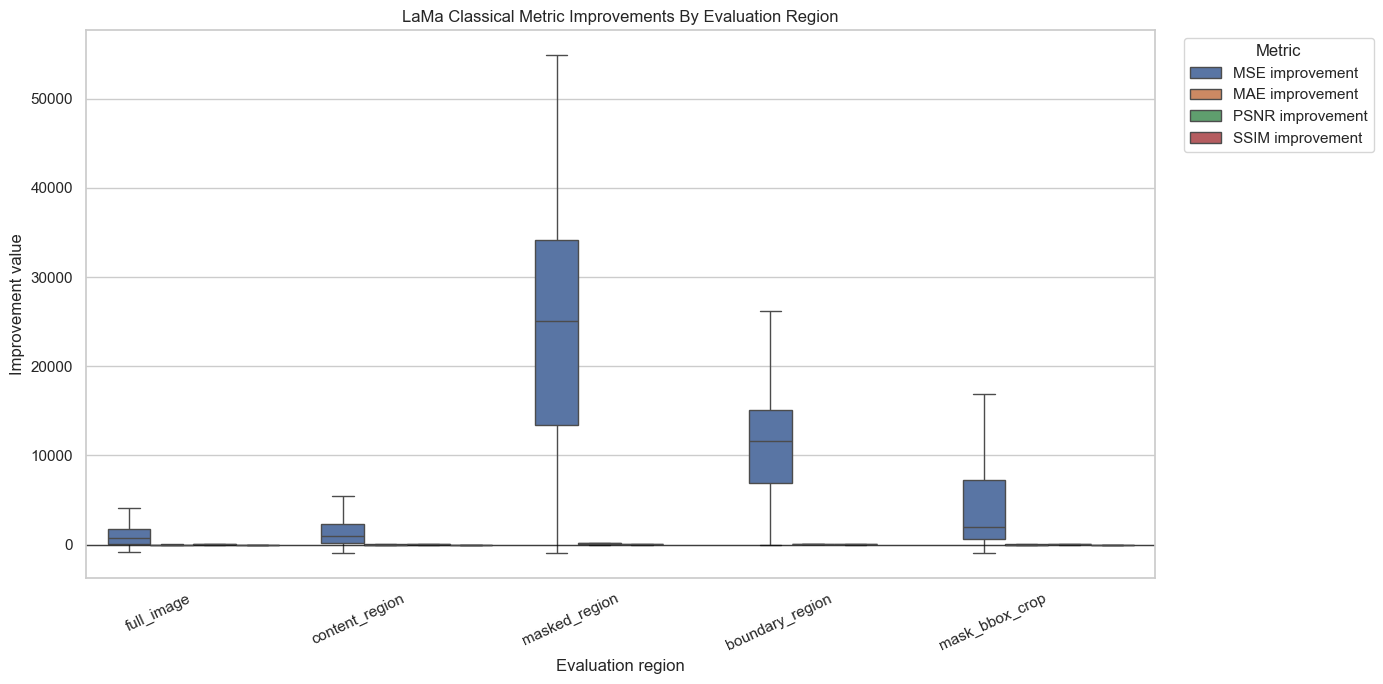

Saved: outputs/metrics/figures/lama_improvement_distributions_by_region.png


In [22]:
region_distribution_path = figures_dir / "lama_improvement_distributions_by_region.png"

region_plot_df = plot_long_df.loc[
    plot_long_df["evaluation_region"].isin(
        ["full_image", "content_region", "mask_bbox_crop", "masked_region", "boundary_region"]
    )
].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=region_plot_df,
    x="evaluation_region",
    y="improvement_value",
    hue="metric_label",
    showfliers=False,
)

plt.axhline(0, color="black", linewidth=1, alpha=0.7)
plt.title("LaMa Classical Metric Improvements By Evaluation Region")
plt.xlabel("Evaluation region")
plt.ylabel("Improvement value")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(region_distribution_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", project_relative_path(region_distribution_path))

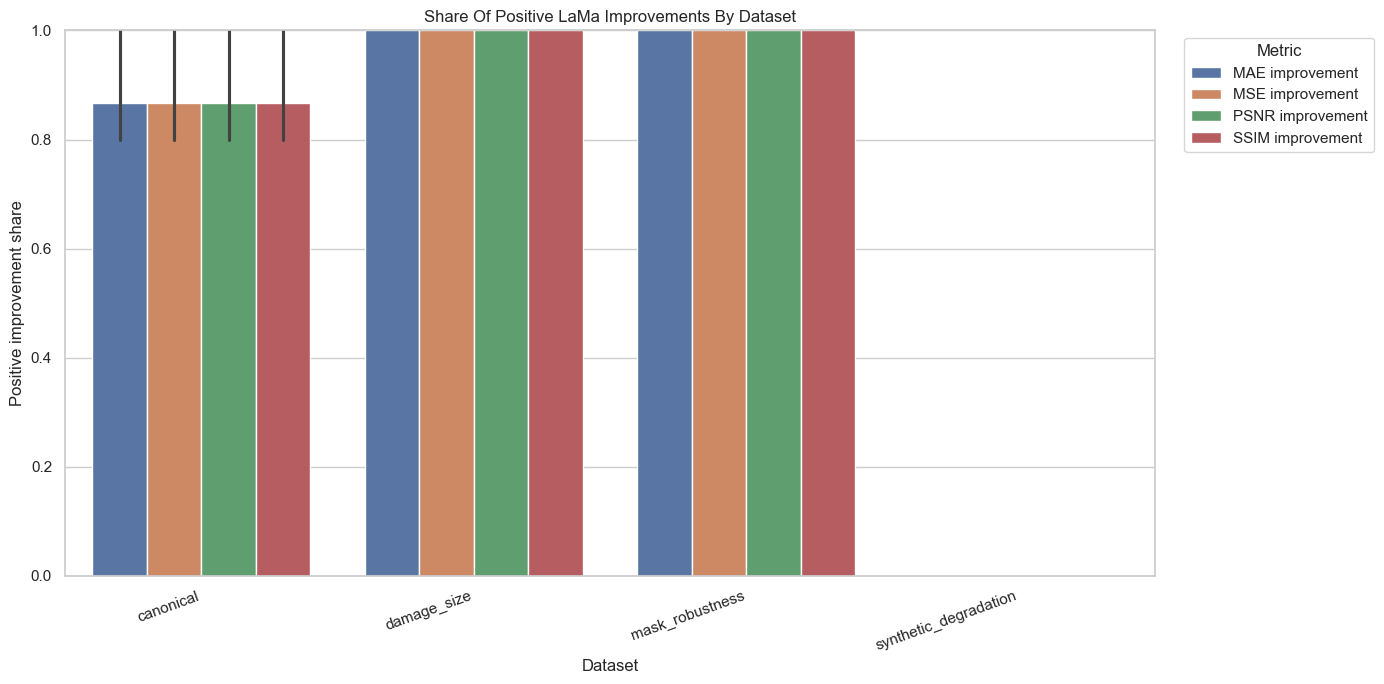

Saved: outputs/metrics/figures/lama_positive_improvement_share_by_dataset.png


,dataset_name,evaluation_region,metric_label,valid_count,positive_share,median_improvement
3,canonical,content_region,MAE improvement,250,0.8,5.703877
4,canonical,content_region,MSE improvement,250,0.8,993.818838
5,canonical,content_region,PSNR improvement,250,0.8,17.047447
6,canonical,content_region,SSIM improvement,250,0.8,0.031078
7,canonical,full_image,MAE improvement,250,0.8,4.344278
8,canonical,full_image,MSE improvement,250,0.8,734.434097
9,canonical,full_image,PSNR improvement,250,0.8,17.047447
10,canonical,full_image,SSIM improvement,250,0.8,0.024896
11,canonical,mask_bbox_crop,MAE improvement,200,1.0,11.559035
12,canonical,mask_bbox_crop,MSE improvement,200,1.0,2117.309494


In [23]:
dataset_improvement_share_path = figures_dir / "lama_positive_improvement_share_by_dataset.png"

positive_share_df = (
    plot_long_df.groupby(["dataset_name", "evaluation_region", "metric_label"], dropna=False)
    .agg(
        valid_count=("improvement_value", "count"),
        positive_share=("improvement_value", lambda values: float((values > 0).mean())),
        median_improvement=("improvement_value", "median"),
    )
    .reset_index()
)

positive_share_plot_df = positive_share_df.loc[
    positive_share_df["evaluation_region"].isin(["full_image", "content_region", "mask_bbox_crop"])
].copy()

plt.figure(figsize=(14, 7))
sns.barplot(
    data=positive_share_plot_df,
    x="dataset_name",
    y="positive_share",
    hue="metric_label",
)

plt.ylim(0, 1)
plt.title("Share Of Positive LaMa Improvements By Dataset")
plt.xlabel("Dataset")
plt.ylabel("Positive improvement share")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(dataset_improvement_share_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", project_relative_path(dataset_improvement_share_path))
display(positive_share_plot_df.head(20))

In [24]:
diagnostic_region = "mask_bbox_crop"

diagnostic_base_df = plot_metrics_df.loc[
    plot_metrics_df["evaluation_region"].astype(str).eq(diagnostic_region)
].copy()

if diagnostic_base_df.empty:
    raise RuntimeError(f"No rows found for diagnostic region: {diagnostic_region}")

diagnostic_score_columns = [
    column for column in ["mse_improvement", "mae_improvement", "psnr_improvement", "ssim_improvement"]
    if column in diagnostic_base_df.columns
]

for column in diagnostic_score_columns:
    diagnostic_base_df[column] = pd.to_numeric(diagnostic_base_df[column], errors="coerce")

rank_metric = "psnr_improvement" if "psnr_improvement" in diagnostic_base_df.columns else diagnostic_score_columns[0]

diagnostic_rows = []

for dataset_name, dataset_df in diagnostic_base_df.groupby("dataset_name", sort=False):
    valid_df = dataset_df.dropna(subset=[rank_metric]).copy()

    if valid_df.empty:
        continue

    best_row = valid_df.sort_values(rank_metric, ascending=False).iloc[0].copy()
    best_row["diagnostic_reason"] = f"best_{rank_metric}"

    worst_row = valid_df.sort_values(rank_metric, ascending=True).iloc[0].copy()
    worst_row["diagnostic_reason"] = f"worst_{rank_metric}"

    median_idx = (valid_df[rank_metric] - valid_df[rank_metric].median()).abs().sort_values().index[0]
    median_row = valid_df.loc[median_idx].copy()
    median_row["diagnostic_reason"] = f"median_{rank_metric}"

    diagnostic_rows.extend([best_row, median_row, worst_row])

diagnostic_cases_df = (
    pd.DataFrame(diagnostic_rows)
    .drop_duplicates(subset=["dataset_name", "case_id", "evaluation_region", "diagnostic_reason"])
    .reset_index(drop=True)
)

diagnostic_columns = [
    column for column in [
        "diagnostic_reason",
        "dataset_name",
        "case_id",
        "restoration_case_id",
        "painting_id",
        "category",
        "mask_type",
        "evaluation_region",
        "has_nonzero_mask",
        "damaged_mse",
        "restored_mse",
        "mse_improvement",
        "damaged_mae",
        "restored_mae",
        "mae_improvement",
        "damaged_psnr",
        "restored_psnr",
        "psnr_improvement",
        "damaged_ssim",
        "restored_ssim",
        "ssim_improvement",
        "clean_path",
        "damaged_path",
        "mask_path",
        "restored_path",
    ]
    if column in diagnostic_cases_df.columns
]

diagnostic_cases_df = diagnostic_cases_df[diagnostic_columns].copy()

display(diagnostic_cases_df)

,diagnostic_reason,dataset_name,case_id,restoration_case_id,painting_id,category,mask_type,evaluation_region,has_nonzero_mask,damaged_mse,...,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,clean_path,damaged_path,mask_path,restored_path
0,best_psnr_improvement,canonical,canonical__p006_loss_small,lama__canonical__canonical__p006_loss_small,p006,portrait_figure,loss_small,mask_bbox_crop,True,3086.408203,...,13.236270,48.675618,35.439348,0.923570,0.994986,0.071417,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,median_psnr_improvement,canonical,canonical__p023_loss_small,lama__canonical__canonical__p023_loss_small,p023,architecture_structured,loss_small,mask_bbox_crop,True,2856.443115,...,13.572548,32.254642,18.682094,0.876543,0.951296,0.074754,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,worst_psnr_improvement,canonical,canonical__p009_loss_large,lama__canonical__canonical__p009_loss_large,p009,portrait_figure,loss_large,mask_bbox_crop,True,7920.890137,...,9.143064,16.306676,7.163612,0.560431,0.612208,0.051776,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,best_psnr_improvement,damage_size,damage_size__p026__loss_large__size_02pct,lama__damage_size__damage_size__p026__loss_lar...,p026,architecture_structured,,mask_bbox_crop,True,7391.853027,...,9.443270,35.671675,26.228405,0.645658,0.875205,0.229547,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,median_psnr_improvement,damage_size,damage_size__p001__loss_large__size_08pct,lama__damage_size__damage_size__p001__loss_lar...,p001,portrait_figure,,mask_bbox_crop,True,25284.478516,...,4.102264,21.271294,17.169030,0.489170,0.807780,0.318610,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
5,worst_psnr_improvement,damage_size,damage_size__p018__loss_large__size_02pct,lama__damage_size__damage_size__p018__loss_lar...,p018,landscape_natural,,mask_bbox_crop,True,10120.254883,...,8.078889,16.805438,8.726549,0.565939,0.747939,0.182000,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
6,best_psnr_improvement,mask_robustness,mask_robustness__p001__scratch_thin__variant_01,lama__mask_robustness__mask_robustness__p001__...,p001,portrait_figure,,mask_bbox_crop,True,3535.292236,...,12.646550,45.279232,32.632681,0.905179,0.987462,0.082283,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
7,median_psnr_improvement,mask_robustness,mask_robustness__p039__scratch_thin__variant_03,lama__mask_robustness__mask_robustness__p039__...,p039,abstraction_surrealism,,mask_bbox_crop,True,459.251404,...,21.510299,41.759896,20.249597,0.941811,0.991437,0.049625,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
8,worst_psnr_improvement,mask_robustness,mask_robustness__p039__loss_large__variant_03,lama__mask_robustness__mask_robustness__p039__...,p039,abstraction_surrealism,,mas

In [25]:
diagnostic_cases_df.to_csv(diagnostic_cases_path, index=False)

batch_6_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "region_distribution_plot",
            "path": project_relative_path(region_distribution_path),
            "rows": "n/a",
            "size_mb": round(region_distribution_path.stat().st_size / (1024 * 1024), 3),
        },
        {
            "artifact": "dataset_positive_share_plot",
            "path": project_relative_path(dataset_improvement_share_path),
            "rows": "n/a",
            "size_mb": round(dataset_improvement_share_path.stat().st_size / (1024 * 1024), 3),
        },
        {
            "artifact": "lama_diagnostic_cases",
            "path": project_relative_path(diagnostic_cases_path),
            "rows": len(diagnostic_cases_df),
            "size_mb": round(diagnostic_cases_path.stat().st_size / (1024 * 1024), 3),
        },
    ]
)

display(batch_6_outputs_df)

,artifact,path,rows,size_mb
0,region_distribution_plot,outputs/metrics/figures/lama_improvement_distr...,n/a,0.122
1,dataset_positive_share_plot,outputs/metrics/figures/lama_positive_improvem...,n/a,0.111
2,lama_diagnostic_cases,outputs/metrics/diagnostics/lama_diagnostic_ca...,12,0.011


In [31]:
from PIL import Image, ImageOps
import textwrap

diagnostic_panels_dir = diagnostics_dir / "panels"
diagnostic_panels_dir.mkdir(parents=True, exist_ok=True)

print("Diagnostic panels dir:", project_relative_path(diagnostic_panels_dir))

Diagnostic panels dir: outputs/metrics/diagnostics/panels


In [32]:
def load_rgb_image(path: str | Path, *, target_size: int | tuple[int, int] | None = None) -> Image.Image:
    image = Image.open(path).convert("RGB")
    resize_size = normalize_target_size(target_size)

    if resize_size is not None:
        image = image.resize(resize_size, Image.Resampling.LANCZOS)

    return image


def load_mask_preview(path: str | Path, *, target_size: int | tuple[int, int] | None = None) -> Image.Image:
    mask = Image.open(path).convert("L")
    resize_size = normalize_target_size(target_size)

    if resize_size is not None:
        mask = mask.resize(resize_size, Image.Resampling.NEAREST)

    mask = ImageOps.autocontrast(mask)
    return Image.merge("RGB", [mask, mask, mask])


def safe_filename(value: str) -> str:
    return (
        str(value)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
        .replace("__", "_")
    )

def normalize_target_size(target_size: int | tuple[int, int] | None) -> tuple[int, int] | None:
    if target_size is None:
        return None

    if isinstance(target_size, int):
        return (target_size, target_size)

    return tuple(target_size)

def make_diagnostic_panel(row: pd.Series, output_path: Path) -> None:
    clean_image = load_rgb_image(row["clean_path"], target_size=TARGET_SIZE)
    damaged_image = load_rgb_image(row["damaged_path"], target_size=TARGET_SIZE)
    mask_image = load_mask_preview(row["mask_path"], target_size=TARGET_SIZE)
    restored_image = load_rgb_image(row["restored_path"], target_size=TARGET_SIZE)

    panel_images = [
        ("Clean", clean_image),
        ("Damaged", damaged_image),
        ("Mask", mask_image),
        ("LaMa restored", restored_image),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    for axis, (title, image) in zip(axes, panel_images, strict=True):
        axis.imshow(image)
        axis.set_title(title)
        axis.axis("off")

    subtitle_parts = [
        f"{row.get('diagnostic_reason', '')}",
        f"dataset={row.get('dataset_name', '')}",
        f"case={row.get('case_id', '')}",
        f"painting={row.get('painting_id', '')}",
        f"region={row.get('evaluation_region', '')}",
    ]

    metric_parts = []
    for column in ["mse_improvement", "mae_improvement", "psnr_improvement", "ssim_improvement"]:
        if column in row.index and pd.notna(row[column]):
            metric_parts.append(f"{column}={float(row[column]):.4f}")

    title = " | ".join([part for part in subtitle_parts if str(part).strip()])
    metric_line = " | ".join(metric_parts)

    fig.suptitle(
        "\n".join(
            textwrap.wrap(title, width=120)
            + textwrap.wrap(metric_line, width=120)
        ),
        fontsize=11,
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

In [33]:
panel_rows = []

for _, row in diagnostic_cases_df.iterrows():
    panel_filename = (
        safe_filename(row["dataset_name"])
        + "__"
        + safe_filename(row["diagnostic_reason"])
        + "__"
        + safe_filename(row["case_id"])
        + ".png"
    )

    panel_path = diagnostic_panels_dir / panel_filename

    make_diagnostic_panel(row, panel_path)

    panel_rows.append(
        {
            "diagnostic_reason": row["diagnostic_reason"],
            "dataset_name": row["dataset_name"],
            "case_id": row["case_id"],
            "painting_id": row.get("painting_id", ""),
            "panel_path": project_relative_path(panel_path),
            "panel_size_mb": round(panel_path.stat().st_size / (1024 * 1024), 3),
        }
    )

diagnostic_panel_manifest_df = pd.DataFrame(panel_rows)

display(diagnostic_panel_manifest_df)

,diagnostic_reason,dataset_name,case_id,painting_id,panel_path,panel_size_mb
0,best_psnr_improvement,canonical,canonical__p006_loss_small,p006,outputs/metrics/diagnostics/panels/canonical__...,0.501
1,median_psnr_improvement,canonical,canonical__p023_loss_small,p023,outputs/metrics/diagnostics/panels/canonical__...,0.721
2,worst_psnr_improvement,canonical,canonical__p009_loss_large,p009,outputs/metrics/diagnostics/panels/canonical__...,0.964
3,best_psnr_improvement,damage_size,damage_size__p026__loss_large__size_02pct,p026,outputs/metrics/diagnostics/panels/damage_size...,0.731
4,median_psnr_improvement,damage_size,damage_size__p001__loss_large__size_08pct,p001,outputs/metrics/diagnostics/panels/damage_size...,0.736
5,worst_psnr_improvement,damage_size,damage_size__p018__loss_large__size_02pct,p018,outputs/metrics/diagnostics/panels/damage_size...,0.549
6,best_psnr_improvement,mask_robustness,mask_robustness__p001__scratch_thin__variant_01,p001,outputs/metrics/diagnostics/panels/mask_robust...,0.699
7,median_psnr_improvement,mask_robustness,mask_robustness__p039__scratch_thin__variant_03,p039,outputs/metrics/diagnostics/panels/mask_robust...,0.789
8,worst_psnr_improvement,mask_robustness,mask_robustness__p039__loss_large__variant_03,p039,outputs/metrics/diagnostics/panels/mask_robust...,0.792
9,best_psnr_improvement,synthetic_degradation,synthetic_degradation__p026__water_stain__mode...,p026,outputs/metrics/diagnostics/panels/synthetic_d...,0.845


In [34]:
diagnostic_panel_manifest_path = diagnostics_dir / "lama_diagnostic_panel_manifest.csv"

diagnostic_panel_manifest_df.to_csv(diagnostic_panel_manifest_path, index=False)

batch_7_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "lama_diagnostic_panel_manifest",
            "path": project_relative_path(diagnostic_panel_manifest_path),
            "rows": len(diagnostic_panel_manifest_df),
            "size_mb": round(diagnostic_panel_manifest_path.stat().st_size / (1024 * 1024), 3),
        },
        {
            "artifact": "diagnostic_panels_directory",
            "path": project_relative_path(diagnostic_panels_dir),
            "rows": len(diagnostic_panel_manifest_df),
            "size_mb": round(
                sum(path.stat().st_size for path in diagnostic_panels_dir.glob("*.png"))
                / (1024 * 1024),
                3,
            ),
        },
    ]
)

display(batch_7_outputs_df)

,artifact,path,rows,size_mb
0,lama_diagnostic_panel_manifest,outputs/metrics/diagnostics/lama_diagnostic_pa...,12,0.002
1,diagnostic_panels_directory,outputs/metrics/diagnostics/panels,12,9.333


In [35]:
thesis_tables_dir = PROJECT_ROOT / "outputs" / "metrics" / "thesis_tables"
thesis_tables_dir.mkdir(parents=True, exist_ok=True)

thesis_classical_tables_path = thesis_tables_dir / "lama_classical_metric_thesis_tables.csv"

print("Thesis tables dir:", project_relative_path(thesis_tables_dir))
print("Output:", project_relative_path(thesis_classical_tables_path))

Thesis tables dir: outputs/metrics/thesis_tables
Output: outputs/metrics/thesis_tables/lama_classical_metric_thesis_tables.csv


In [36]:
thesis_metrics_df = lama_classical_metrics_df.copy()

thesis_numeric_columns = [
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
]

for column in thesis_numeric_columns:
    if column in thesis_metrics_df.columns:
        thesis_metrics_df[column] = pd.to_numeric(thesis_metrics_df[column], errors="coerce")

thesis_metrics_df = thesis_metrics_df.replace([np.inf, -np.inf], np.nan)

thesis_improvement_columns = [
    column for column in [
        "mse_improvement",
        "mae_improvement",
        "psnr_improvement",
        "ssim_improvement",
    ]
    if column in thesis_metrics_df.columns
]

print("Rows:", len(thesis_metrics_df))
print("Improvement metrics:", thesis_improvement_columns)

Rows: 2260
Improvement metrics: ['mse_improvement', 'mae_improvement', 'psnr_improvement', 'ssim_improvement']


In [37]:
def build_thesis_aggregate_table(
    dataframe: pd.DataFrame,
    *,
    table_name: str,
    group_columns: list[str],
    metric_columns: list[str],
) -> pd.DataFrame:
    present_group_columns = [
        column for column in group_columns
        if column in dataframe.columns
    ]

    rows = []

    for metric_column in metric_columns:
        metric_df = dataframe.loc[dataframe[metric_column].notna()].copy()

        if metric_df.empty:
            continue

        if present_group_columns:
            grouped = metric_df.groupby(present_group_columns, dropna=False, sort=False)
        else:
            grouped = [((), metric_df)]

        for group_key, group_df in grouped:
            if present_group_columns and not isinstance(group_key, tuple):
                group_key = (group_key,)

            row = {
                "table_name": table_name,
                "metric": metric_column,
                "row_count": int(len(group_df)),
                "mean_value": float(group_df[metric_column].mean()),
                "median_value": float(group_df[metric_column].median()),
                "std_value": float(group_df[metric_column].std()) if len(group_df) > 1 else np.nan,
                "min_value": float(group_df[metric_column].min()),
                "max_value": float(group_df[metric_column].max()),
                "positive_improvement_count": int((group_df[metric_column] > 0).sum()),
                "negative_improvement_count": int((group_df[metric_column] < 0).sum()),
                "zero_improvement_count": int((group_df[metric_column] == 0).sum()),
                "positive_improvement_share": float((group_df[metric_column] > 0).mean()),
            }

            for column, value in zip(present_group_columns, group_key, strict=False):
                row[column] = value

            rows.append(row)

    return pd.DataFrame(rows)

In [38]:
aggregate_tables = [
    build_thesis_aggregate_table(
        thesis_metrics_df,
        table_name="overall_by_region",
        group_columns=["evaluation_region"],
        metric_columns=thesis_improvement_columns,
    ),
    build_thesis_aggregate_table(
        thesis_metrics_df,
        table_name="dataset_by_region",
        group_columns=["dataset_name", "evaluation_region"],
        metric_columns=thesis_improvement_columns,
    ),
    build_thesis_aggregate_table(
        thesis_metrics_df,
        table_name="dataset_mask_type_by_region",
        group_columns=["dataset_name", "mask_type", "evaluation_region"],
        metric_columns=thesis_improvement_columns,
    ),
    build_thesis_aggregate_table(
        thesis_metrics_df,
        table_name="category_by_region",
        group_columns=["category", "evaluation_region"],
        metric_columns=thesis_improvement_columns,
    ),
    build_thesis_aggregate_table(
        thesis_metrics_df,
        table_name="applicability_by_region",
        group_columns=["lama_applicability", "evaluation_region"],
        metric_columns=thesis_improvement_columns,
    ),
]

thesis_classical_tables_df = pd.concat(
    [table for table in aggregate_tables if not table.empty],
    ignore_index=True,
)

front_columns = [
    "table_name",
    "dataset_name",
    "evaluation_region",
    "mask_type",
    "category",
    "lama_applicability",
    "metric",
    "row_count",
    "mean_value",
    "median_value",
    "std_value",
    "min_value",
    "max_value",
    "positive_improvement_count",
    "negative_improvement_count",
    "zero_improvement_count",
    "positive_improvement_share",
]

front_columns = [
    column for column in front_columns
    if column in thesis_classical_tables_df.columns
]

remaining_columns = [
    column for column in thesis_classical_tables_df.columns
    if column not in front_columns
]

thesis_classical_tables_df = thesis_classical_tables_df[
    front_columns + remaining_columns
].copy()

print("Thesis aggregate table shape:", thesis_classical_tables_df.shape)
display(thesis_classical_tables_df.head(30))

Thesis aggregate table shape: (407, 17)


,table_name,dataset_name,evaluation_region,mask_type,category,lama_applicability,metric,row_count,mean_value,median_value,std_value,min_value,max_value,positive_improvement_count,negative_improvement_count,zero_improvement_count,positive_improvement_share
0,overall_by_region,NaN,full_image,NaN,NaN,NaN,mse_improvement,410,1114.069121,702.984518,1266.615982,-783.637451,8393.367767,310,45,55,0.756098
1,overall_by_region,NaN,content_region,NaN,NaN,NaN,mse_improvement,410,1451.431152,930.953003,1591.123300,-907.743042,9722.631950,310,45,55,0.756098
2,overall_by_region,NaN,masked_region,NaN,NaN,NaN,mse_improvement,360,23931.677399,25052.024429,14431.531203,-971.973145,54879.527777,310,45,5,0.861111
3,overall_by_region,NaN,boundary_region,NaN,NaN,NaN,mse_improvement,360,11027.321805,11606.010887,6647.024600,-24.388120,27746.510958,310,15,35,0.861111
4,overall_by_region,NaN,outside_mask_region,NaN,NaN,NaN,mse_improvement,360,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,360,0.000000
5,overall_by_region,NaN,mask_bbox_crop,NaN,NaN,NaN,mse_improvement,360,5106.849699,2007.510644,6786.512608,-886.351807,29448.972702,310,45,5,0.861111
6,overall_by_region,NaN,full_image,NaN,NaN,NaN,mae_improvement,410,5.702679,4.058222,6.042504,-6.956503,36.383309,310,45,55,0.756098
7,overall_by_region,NaN,content_region,NaN,NaN,NaN,mae_improvement,410,7.469214,5.148915,7.709086,-8.058228,42.145375,310,45,55,0.756098
8,overall_by_region,NaN,masked_region,NaN,NaN,NaN,mae_improvement,360,124.209236,134.860612,63.523674,-10.368043,230.527690,310,45,5,0.861111
9,overall_by_region,NaN,boundary_region,NaN,NaN,NaN,mae_improvement,360,58.655581,65.498250,29.895076,-0.907499,116.675960,310,15,35,0.861111


In [39]:
thesis_classical_tables_df.to_csv(thesis_classical_tables_path, index=False)

batch_8_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "lama_classical_metric_thesis_tables",
            "path": project_relative_path(thesis_classical_tables_path),
            "rows": len(thesis_classical_tables_df),
            "columns": len(thesis_classical_tables_df.columns),
            "size_mb": round(thesis_classical_tables_path.stat().st_size / (1024 * 1024), 3),
        }
    ]
)

display(batch_8_outputs_df)

,artifact,path,rows,columns,size_mb
0,lama_classical_metric_thesis_tables,outputs/metrics/thesis_tables/lama_classical_m...,407,17,0.068


In [40]:
final_tables_dir = PROJECT_ROOT / "outputs" / "metrics" / "final_tables"
final_tables_dir.mkdir(parents=True, exist_ok=True)

final_dataset_region_table_path = final_tables_dir / "lama_dataset_region_metric_table.csv"
final_damage_setting_table_path = final_tables_dir / "lama_damage_setting_metric_table.csv"
final_artifact_manifest_path = final_tables_dir / "lama_classical_metrics_artifact_manifest.csv"

print("Final tables dir:", project_relative_path(final_tables_dir))

Final tables dir: outputs/metrics/final_tables


In [41]:
final_metric_df = lama_classical_metrics_df.copy()

for column in [
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
]:
    if column in final_metric_df.columns:
        final_metric_df[column] = pd.to_numeric(final_metric_df[column], errors="coerce")

final_metric_df = final_metric_df.replace([np.inf, -np.inf], np.nan)

dataset_region_group_columns = [
    "dataset_name",
    "evaluation_region",
]

dataset_region_metric_columns = [
    column for column in [
        "mse_improvement",
        "mae_improvement",
        "psnr_improvement",
        "ssim_improvement",
        "restored_mse",
        "restored_mae",
        "restored_psnr",
        "restored_ssim",
    ]
    if column in final_metric_df.columns
]

dataset_region_tables = []

for metric_column in dataset_region_metric_columns:
    table_df = (
        final_metric_df.groupby(dataset_region_group_columns, dropna=False, sort=False)
        .agg(
            case_count=(metric_column, "size"),
            valid_count=(metric_column, "count"),
            mean=(metric_column, "mean"),
            median=(metric_column, "median"),
            std=(metric_column, "std"),
            min=(metric_column, "min"),
            max=(metric_column, "max"),
        )
        .reset_index()
    )

    table_df["metric"] = metric_column
    dataset_region_tables.append(table_df)

final_dataset_region_table_df = pd.concat(dataset_region_tables, ignore_index=True)

final_dataset_region_table_df = final_dataset_region_table_df[
    [
        "dataset_name",
        "evaluation_region",
        "metric",
        "case_count",
        "valid_count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ]
].copy()

display(final_dataset_region_table_df.head(30))

,dataset_name,evaluation_region,metric,case_count,valid_count,mean,median,std,min,max
0,canonical,full_image,mse_improvement,250,250,1129.005844,734.434097,1133.838459,0.000000,5660.389977
1,canonical,content_region,mse_improvement,250,250,1472.340113,993.818838,1453.797954,0.000000,6591.247646
2,canonical,masked_region,mse_improvement,200,200,26852.898037,27161.071442,11433.246336,3184.144104,54259.773041
3,canonical,boundary_region,mse_improvement,200,200,12082.739929,12674.220619,5026.038291,1573.233754,26222.200210
4,canonical,outside_mask_region,mse_improvement,200,200,0.000000,0.000000,0.000000,0.000000,0.000000
5,canonical,mask_bbox_crop,mse_improvement,200,200,4421.290371,2117.309494,5710.572144,55.600415,26794.820190
6,damage_size,full_image,mse_improvement,35,35,1954.540428,1414.141777,1834.363453,179.637213,8393.367767
7,damage_size,content_region,mse_improvement,35,35,2519.820899,1893.780716,2171.223764,244.612319,9722.631950
8,damage_size,masked_region,mse_improvement,35,35,26667.047511,23642.714783,12611.081364,12202.500092,48584.834961
9,damage_size,boundary_region,mse_improvement,35,35,13799.297495,12661.804047,6423.197734,5903.557159,25581.062442


In [42]:
damage_setting_group_columns = [
    column for column in [
        "dataset_name",
        "mask_type",
        "category",
        "source_mask_semantics",
        "lama_applicability",
        "evaluation_region",
    ]
    if column in final_metric_df.columns
]

damage_setting_tables = []

for metric_column in dataset_region_metric_columns:
    table_df = (
        final_metric_df.groupby(damage_setting_group_columns, dropna=False, sort=False)
        .agg(
            case_count=(metric_column, "size"),
            valid_count=(metric_column, "count"),
            mean=(metric_column, "mean"),
            median=(metric_column, "median"),
            std=(metric_column, "std"),
            min=(metric_column, "min"),
            max=(metric_column, "max"),
        )
        .reset_index()
    )

    table_df["metric"] = metric_column
    damage_setting_tables.append(table_df)

final_damage_setting_table_df = pd.concat(damage_setting_tables, ignore_index=True)

final_damage_setting_table_df = final_damage_setting_table_df[
    damage_setting_group_columns
    + [
        "metric",
        "case_count",
        "valid_count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ]
].copy()

display(final_damage_setting_table_df.head(30))

,dataset_name,mask_type,category,source_mask_semantics,lama_applicability,evaluation_region,metric,case_count,valid_count,mean,median,std,min,max
0,canonical,loss_large,portrait_figure,binary_missing_content,primary,full_image,mse_improvement,10,10,3485.571467,3629.751904,1410.039088,1193.023285,5660.389977
1,canonical,loss_large,portrait_figure,binary_missing_content,primary,content_region,mse_improvement,10,10,4449.000859,4720.424942,1584.920150,1484.995667,6591.247646
2,canonical,loss_large,portrait_figure,binary_missing_content,primary,masked_region,mse_improvement,10,10,35574.786293,36926.638641,10370.531991,12809.674316,48485.230362
3,canonical,loss_large,portrait_figure,binary_missing_content,primary,boundary_region,mse_improvement,10,10,18875.948886,19124.839204,4942.664349,8445.865013,25396.024811
4,canonical,loss_large,portrait_figure,binary_missing_content,primary,outside_mask_region,mse_improvement,10,10,0.000000,0.000000,0.000000,0.000000,0.000000
5,canonical,loss_large,portrait_figure,binary_missing_content,primary,mask_bbox_crop,mse_improvement,10,10,18145.699474,19031.992599,6523.498346,6398.896729,26794.820190
6,canonical,loss_small,portrait_figure,binary_missing_content,primary,full_image,mse_improvement,10,10,1239.389283,1338.491409,329.502473,603.628233,1677.863233
7,canonical,loss_small,portrait_figure,binary_missing_content,primary,content_region,mse_improvement,10,10,1623.127663,1594.907266,490.002222,751.355722,2387.366075
8,canonical,loss_small,portrait_figure,binary_missing_content,primary,masked_region,mse_improvement,10,10,37865.912204,39178.709732,10517.431535,19712.888000,54259.773041
9,canonical,loss_small,portrait_figure,binary_missing_content,primary,boundary_region,mse_improvement,10,10,18562.272587,19110.840333,4822.632732,9581.001137,26222.200210


In [43]:
final_dataset_region_table_df.to_csv(final_dataset_region_table_path, index=False)
final_damage_setting_table_df.to_csv(final_damage_setting_table_path, index=False)

final_table_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "lama_dataset_region_metric_table",
            "path": project_relative_path(final_dataset_region_table_path),
            "rows": len(final_dataset_region_table_df),
            "columns": len(final_dataset_region_table_df.columns),
            "size_mb": round(final_dataset_region_table_path.stat().st_size / (1024 * 1024), 3),
        },
        {
            "artifact": "lama_damage_setting_metric_table",
            "path": project_relative_path(final_damage_setting_table_path),
            "rows": len(final_damage_setting_table_df),
            "columns": len(final_damage_setting_table_df.columns),
            "size_mb": round(final_damage_setting_table_path.stat().st_size / (1024 * 1024), 3),
        },
    ]
)

display(final_table_outputs_df)

,artifact,path,rows,columns,size_mb
0,lama_dataset_region_metric_table,outputs/metrics/final_tables/lama_dataset_regi...,192,10,0.023
1,lama_damage_setting_metric_table,outputs/metrics/final_tables/lama_damage_setti...,1760,14,0.307


In [44]:
artifact_manifest_rows = [
    {
        "artifact": "classical_metrics_lama",
        "path": project_relative_path(classical_metrics_path),
        "status": "created",
    },
    {
        "artifact": "classical_metrics_lama_summary",
        "path": project_relative_path(classical_metrics_summary_path),
        "status": "created",
    },
    {
        "artifact": "classical_metrics_lama_audit",
        "path": project_relative_path(classical_metrics_audit_path),
        "status": "created",
    },
    {
        "artifact": "lama_diagnostic_cases",
        "path": project_relative_path(diagnostic_cases_path),
        "status": "created",
    },
    {
        "artifact": "lama_diagnostic_panel_manifest",
        "path": project_relative_path(diagnostic_panel_manifest_path),
        "status": "created",
    },
    {
        "artifact": "lama_dataset_region_metric_table",
        "path": project_relative_path(final_dataset_region_table_path),
        "status": "created",
    },
    {
        "artifact": "lama_damage_setting_metric_table",
        "path": project_relative_path(final_damage_setting_table_path),
        "status": "created",
    },
]

final_artifact_manifest_df = pd.DataFrame(artifact_manifest_rows)

final_artifact_manifest_df.to_csv(final_artifact_manifest_path, index=False)

display(final_artifact_manifest_df)

print("Saved:", project_relative_path(final_artifact_manifest_path))

,artifact,path,status
0,classical_metrics_lama,outputs/metrics/classical_metrics_lama.csv,created
1,classical_metrics_lama_summary,outputs/metrics/classical_metrics_lama_summary...,created
2,classical_metrics_lama_audit,outputs/metrics/classical_metrics_lama_audit.csv,created
3,lama_diagnostic_cases,outputs/metrics/diagnostics/lama_diagnostic_ca...,created
4,lama_diagnostic_panel_manifest,outputs/metrics/diagnostics/lama_diagnostic_pa...,created
5,lama_dataset_region_metric_table,outputs/metrics/final_tables/lama_dataset_regi...,created
6,lama_damage_setting_metric_table,outputs/metrics/final_tables/lama_damage_setti...,created


Saved: outputs/metrics/final_tables/lama_classical_metrics_artifact_manifest.csv
